In [ ]:
# Gerekli aracı (kütüphaneyi) içeri alıyoruz
import pandas as pd

# 1. Yüklediğimiz CSV dosyasını okuyup 'df' (dataframe) adında bir tabloya atıyoruz
df = pd.read_csv('../data/nasa.csv')

# 2. Tablonun boyutunu görelim (Kaç satır, kaç sütun var?)
print("Veri setinin orijinal boyutu:", df.shape)

# 3. Ödev raporunda belirttiğimiz gereksiz ve sabit sütunları siliyoruz.
# 'axis=1' demek sütun sileceğiz demektir. 'inplace=True' ise bu işlemi kalıcı yapar.
silinecek_sutunlar = ['Neo Reference ID', 'Name', 'Orbiting Body', 'Equinox']
df.drop(silinecek_sutunlar, axis=1, inplace=True)

# 4. Çoklu doğrusallık yapacak olan, aynı anlama gelen farklı birimlerdeki ölçüleri de siliyoruz
birim_fazlaliklari = [
    'Est Dia in M(min)', 'Est Dia in M(max)',       # Çap (Metre) siliyoruz, KM kalacak
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)', # Çap (Mil) siliyoruz
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',   # Çap (Fit) siliyoruz
    'Relative Velocity km per hr', 'Miles per hour',  # Hız birimlerini siliyoruz, km/s kalacak
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(miles)' # Mesafe birimlerini siliyoruz, KM kalacak
]
df.drop(birim_fazlaliklari, axis=1, inplace=True)

# 5. Temizlikten sonra tablonun yeni boyutunu görelim
print("Gereksiz sütunlar silindikten sonraki boyut:", df.shape)

# Tablonun ilk 3 satırına hızlıca bir göz atalım
df.head(3)

Veri setinin orijinal boyutu: (4687, 40)
Gereksiz sütunlar silindikten sonraki boyut: (4687, 25)


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Close Approach Date,Epoch Date Close Approach,Relative Velocity km per sec,Miss Dist.(kilometers),Orbit ID,Orbit Determination Date,Orbit Uncertainity,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,21.6,0.127220,0.284472,1995-01-01,788947200000,6.115834,62753692.0,17,2017-04-06 08:36:37,5,...,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,True
1,21.3,0.146068,0.326618,1995-01-01,788947200000,18.113985,57298148.0,21,2017-04-06 08:32:49,3,...,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,False
2,20.3,0.231502,0.517654,1995-01-08,789552000000,7.590711,7622911.5,22,2017-04-06 09:20:19,0,...,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,True


In [ ]:
# 1. Önce tahmin etmeye çalıştığımız hedef değişkeni (Hazardous) ayarlayalım.
# True/False değerlerini, makine öğrenmesi modellerinin anlayabilmesi için 1 ve 0'a çeviriyoruz.
y = df['Hazardous'].astype(int)

# ---------------------------------------------------------
# SENARYO 1: LİTERATÜRDEKİ YANILTICI MODEL (Sızıntılı)
# ---------------------------------------------------------
# Hedef değişkeni (Hazardous) veriden çıkarıyoruz, geri kalan HER ŞEY modelin kopyası (X_leak).
X_leak = df.drop('Hazardous', axis=1)


# ---------------------------------------------------------
# SENARYO 2: BİZİM GERÇEKÇİ MODELİMİZ (Temiz)
# ---------------------------------------------------------
# Sızıntı yapan o iki kopya çekme sütununu belirliyoruz.
sizinti_sutunlari = ['Absolute Magnitude', 'Minimum Orbit Intersection']

# Yanıltıcı modelden bu iki sütunu da atıp tamamen temiz, sızıntısız bir veri seti (X_clean) elde ediyoruz.
X_clean = X_leak.drop(sizinti_sutunlari, axis=1)


# ---------------------------------------------------------
# VERİYİ EĞİTİM (%80) VE TEST (%20) OLARAK BÖLME
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split

# Önce Sızıntılı veriyi bölelim.
# stratify=y komutu çok kritiktir: %16'lık tehlikeli sınıfın hem eğitime hem teste eşit oranda düşmesini sağlar.
X_train_leak, X_test_leak, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.20, random_state=42, stratify=y
)

# Şimdi de Temiz veriyi bölelim.
# Hedef değişken (y) aynı olduğu için y_train ve y_test'i tekrar üretmemize gerek yok.
X_train_clean, X_test_clean, _, _ = train_test_split(
    X_clean, y, test_size=0.20, random_state=42, stratify=y
)

print("Sızıntılı Veri (Kopya Çeken) Eğitim Seti Sütun Sayısı:", X_train_leak.shape[1])
print("Temiz Veri (Gerçekçi) Eğitim Seti Sütun Sayısı:", X_train_clean.shape[1])
print("\nEğitim setindeki veri sayısı:", X_train_clean.shape[0])
print("Test setindeki veri sayısı:", X_test_clean.shape[0])

Sızıntılı Veri (Kopya Çeken) Eğitim Seti Sütun Sayısı: 24
Temiz Veri (Gerçekçi) Eğitim Seti Sütun Sayısı: 22

Eğitim setindeki veri sayısı: 3749
Test setindeki veri sayısı: 938


In [ ]:
# 1. Veri setindeki tüm metin (string/tarih) tabanlı sütunları bulup siliyoruz.
metin_sutunlari = df.select_dtypes(include=['object']).columns
df.drop(metin_sutunlari, axis=1, inplace=True)
print("Silinen metin/tarih sütunları:", list(metin_sutunlari))

# 2. X_leak ve X_clean veri setlerini, bu güncel (tarihsiz) df üzerinden YENİDEN oluşturuyoruz.
X_leak = df.drop('Hazardous', axis=1)
X_clean = X_leak.drop(['Absolute Magnitude', 'Minimum Orbit Intersection'], axis=1)

# 3. Veriyi YENİDEN bölüyoruz.
from sklearn.model_selection import train_test_split
X_train_leak, X_test_leak, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.20, random_state=42, stratify=y
)
X_train_clean, X_test_clean, _, _ = train_test_split(
    X_clean, y, test_size=0.20, random_state=42, stratify=y
)

# 4. ŞİMDİ HATA ALDIĞIMIZ ÖLÇEKLENDİRME VE SMOTE İŞLEMİNİ TEKRAR DENİYORUZ
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_leak_scaled = scaler.fit_transform(X_train_leak)
X_test_leak_scaled = scaler.transform(X_test_leak)

X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled = scaler.transform(X_test_clean)

smote = SMOTE(random_state=42)
X_train_leak_smote, y_train_leak_smote = smote.fit_resample(X_train_leak_scaled, y_train)
X_train_clean_smote, y_train_clean_smote = smote.fit_resample(X_train_clean_scaled, y_train)

print("\nHATA ÇÖZÜLDÜ! Yeni SMOTE Sonrası Eğitim Seti Sınıf Dağılımı:")
print(y_train_clean_smote.value_counts())

Silinen metin/tarih sütunları: ['Close Approach Date', 'Orbit Determination Date']

HATA ÇÖZÜLDÜ! Yeni SMOTE Sonrası Eğitim Seti Sınıf Dağılımı:
Hazardous
0    3145
1    3145
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Modellerin Tanımlanması
# Baseline Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
# Ağaç Tabanlı Modeller
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

print("--- TEMİZ VERİ SETİ SONUÇLARI (Projenin Gerçekçi Başarımı) ---\n")

# Lojistik Regresyon Eğitimi ve Testi
log_reg.fit(X_train_clean_smote, y_train_clean_smote)
y_pred_log = log_reg.predict(X_test_clean_scaled)
print("[ Lojistik Regresyon ]")
print(classification_report(y_test, y_pred_log))

# Random Forest Eğitimi ve Testi
rf_model.fit(X_train_clean_smote, y_train_clean_smote)
y_pred_rf = rf_model.predict(X_test_clean_scaled)
print("\n[ Random Forest ]")
print(classification_report(y_test, y_pred_rf))

# XGBoost Eğitimi ve Testi
xgb_model.fit(X_train_clean_smote, y_train_clean_smote)
y_pred_xgb = xgb_model.predict(X_test_clean_scaled)
print("\n[ XGBoost ]")
print(classification_report(y_test, y_pred_xgb))

print("\n==============================================================")
print("\n--- SIZINTILI VERİ SETİ SONUCU (Literatürdeki Hedef Sızıntısı) ---")

# Sızıntılı (Target Leakage) veri üzerinde Random Forest eğitimi
rf_leak = RandomForestClassifier(n_estimators=100, random_state=42)
rf_leak.fit(X_train_leak_smote, y_train_leak_smote)
y_pred_leak = rf_leak.predict(X_test_leak_scaled)
print("\n[ Random Forest - Sızıntılı ]")
print(classification_report(y_test, y_pred_leak))

--- TEMİZ VERİ SETİ SONUÇLARI (Projenin Gerçekçi Başarımı) ---

[ Lojistik Regresyon ]
              precision    recall  f1-score   support

           0       0.95      0.72      0.81       787
           1       0.35      0.79      0.48       151

    accuracy                           0.73       938
   macro avg       0.65      0.75      0.65       938
weighted avg       0.85      0.73      0.76       938


[ Random Forest ]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       787
           1       0.72      0.84      0.77       151

    accuracy                           0.92       938
   macro avg       0.84      0.89      0.86       938
weighted avg       0.93      0.92      0.92       938



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[ XGBoost ]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       787
           1       0.80      0.86      0.83       151

    accuracy                           0.94       938
   macro avg       0.89      0.91      0.90       938
weighted avg       0.94      0.94      0.94       938



--- SIZINTILI VERİ SETİ SONUCU (Literatürdeki Hedef Sızıntısı) ---

[ Random Forest - Sızıntılı ]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       0.99      0.99      0.99       151

    accuracy                           1.00       938
   macro avg       1.00      1.00      1.00       938
weighted avg       1.00      1.00      1.00       938



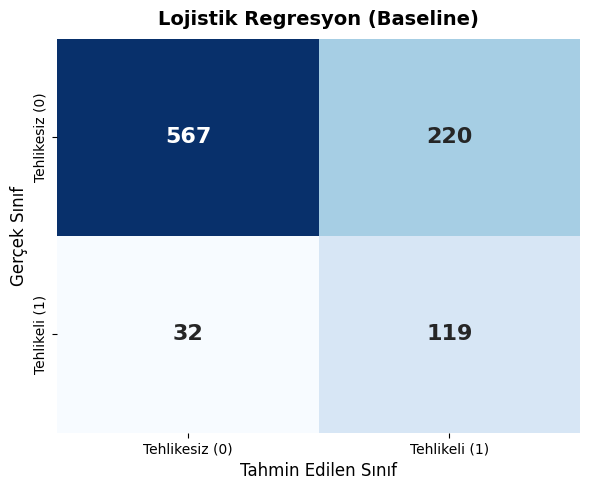

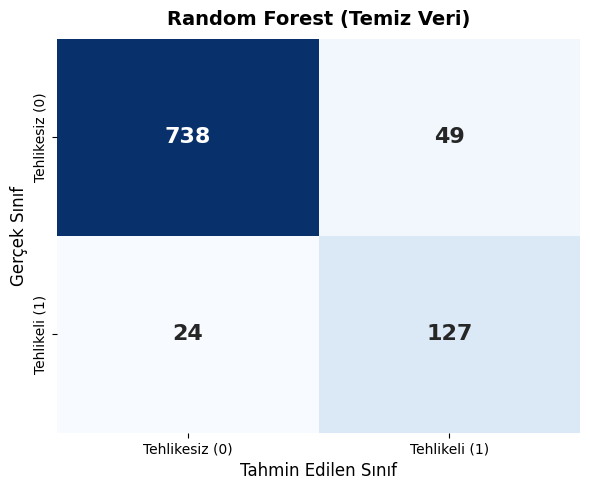

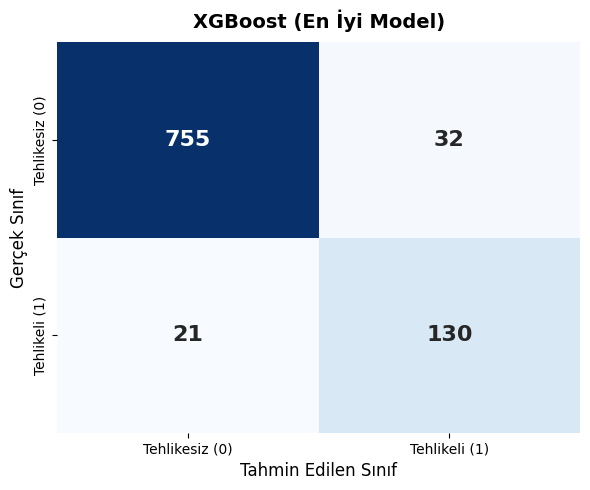

/tmp/ipykernel_6227/1475800837.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:10]], y=X_clean.columns[indices[:10]], palette="viridis")


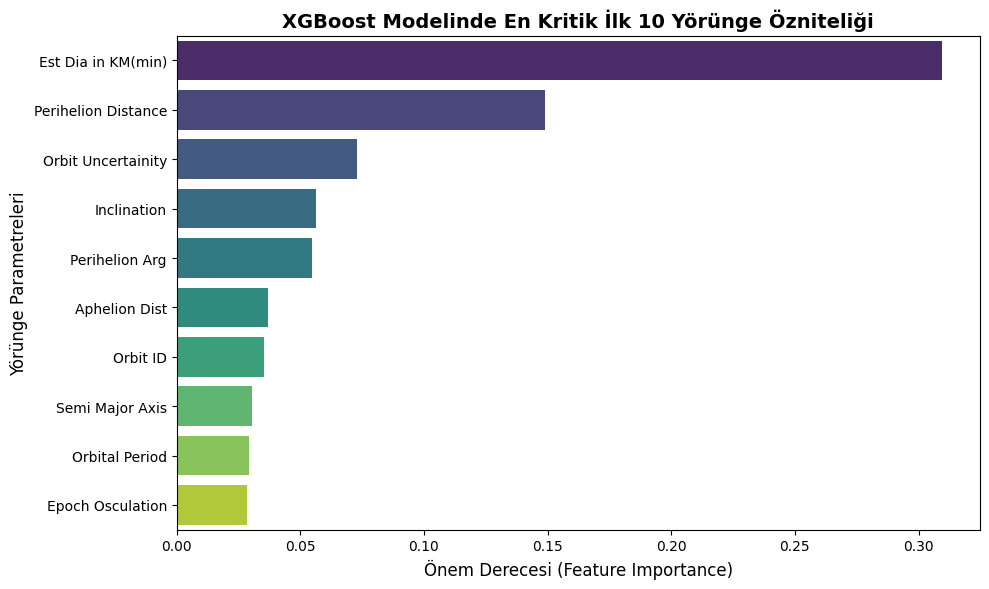

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modellerin ürettiği net matris değerleri [TN, FP, FN, TP]
matrices = {
    "Lojistik Regresyon (Baseline)": [567, 220, 32, 119],
    "Random Forest (Temiz Veri)": [738, 49, 24, 127],
    "XGBoost (En İyi Model)": [755, 32, 21, 130]
}

# Dosya kaydetme isimleri
filenames = {
    "Lojistik Regresyon (Baseline)": "cm_lojistik.png",
    "Random Forest (Temiz Veri)": "cm_rf.png",
    "XGBoost (En İyi Model)": "cm_xgb.png"
}

# 1. Matrisleri TEK TEK çizdirip kaydediyoruz
for model_name, counts in matrices.items():
    cm = np.array([[counts[0], counts[1]], [counts[2], counts[3]]])

    plt.figure(figsize=(6, 5)) # Her biri için yeni ve ideal boyutta figür
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tehlikesiz (0)', 'Tehlikeli (1)'],
                yticklabels=['Tehlikesiz (0)', 'Tehlikeli (1)'],
                annot_kws={"size": 16, "weight": "bold"})

    plt.title(model_name, fontsize=14, weight='bold', pad=10)
    plt.xlabel('Tahmin Edilen Sınıf', fontsize=12)
    plt.ylabel('Gerçek Sınıf', fontsize=12)
    plt.tight_layout()
    plt.savefig(filenames[model_name], dpi=300)
    plt.show()

# 2. Öznitelik Önem Derecelerini Çizdirme (Aynı kalıyor)
plt.figure(figsize=(10, 6))
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices[:10]], y=X_clean.columns[indices[:10]], palette="viridis")
plt.title('XGBoost Modelinde En Kritik İlk 10 Yörünge Özniteliği', fontsize=14, weight='bold')
plt.xlabel('Önem Derecesi (Feature Importance)', fontsize=12)
plt.ylabel('Yörünge Parametreleri', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=300)
plt.show()

In [ ]:
import joblib

# 1. Modeli kaydet
joblib.dump(xgb_model, '../xgboost_asteroid_model.pkl')

# 2. Scaler'ı kaydet
joblib.dump(scaler, '../asteroid_scaler.pkl')

# 3. Özellik (Feature) isimlerini sırasıyla kaydet
joblib.dump(X_clean.columns.tolist(), '../feature_names.pkl')

print("Dosyalar başarıyla kaydedildi! Sol taraftaki klasör ikonundan indirebilirsin.")

Dosyalar başarıyla kaydedildi! Sol taraftaki klasör ikonundan indirebilirsin.


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# XGBoost modelinin olasılık tahminlerini alıyoruz
y_pred_proba_xgb = xgb_model.predict_proba(X_test_clean_scaled)[:, 1]

# ROC-AUC ve PR-AUC değerlerini hesaplıyoruz
roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc = average_precision_score(y_test, y_pred_proba_xgb)

print(f"XGBoost ROC-AUC Skoru: {roc_auc:.3f}")
print(f"XGBoost PR-AUC Skoru: {pr_auc:.3f}")

XGBoost ROC-AUC Skoru: 0.976
XGBoost PR-AUC Skoru: 0.896


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Lojistik Regresyon için değerler
y_prob_log = log_reg.predict_proba(X_test_clean_scaled)[:, 1]
print(f"Lojistik Regresyon -> ROC-AUC: {roc_auc_score(y_test, y_prob_log):.3f} | PR-AUC: {average_precision_score(y_test, y_prob_log):.3f}")

# Random Forest (Temiz) için değerler
y_prob_rf = rf_model.predict_proba(X_test_clean_scaled)[:, 1]
print(f"Random Forest (Temiz) -> ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f} | PR-AUC: {average_precision_score(y_test, y_prob_rf):.3f}")

# Random Forest (Sızıntılı) için değerler
y_prob_leak = rf_leak.predict_proba(X_test_leak_scaled)[:, 1]
print(f"Random Forest (Sızıntılı) -> ROC-AUC: {roc_auc_score(y_test, y_prob_leak):.3f} | PR-AUC: {average_precision_score(y_test, y_prob_leak):.3f}")

Lojistik Regresyon -> ROC-AUC: 0.823 | PR-AUC: 0.451
Random Forest (Temiz) -> ROC-AUC: 0.970 | PR-AUC: 0.863
Random Forest (Sızıntılı) -> ROC-AUC: 1.000 | PR-AUC: 1.000


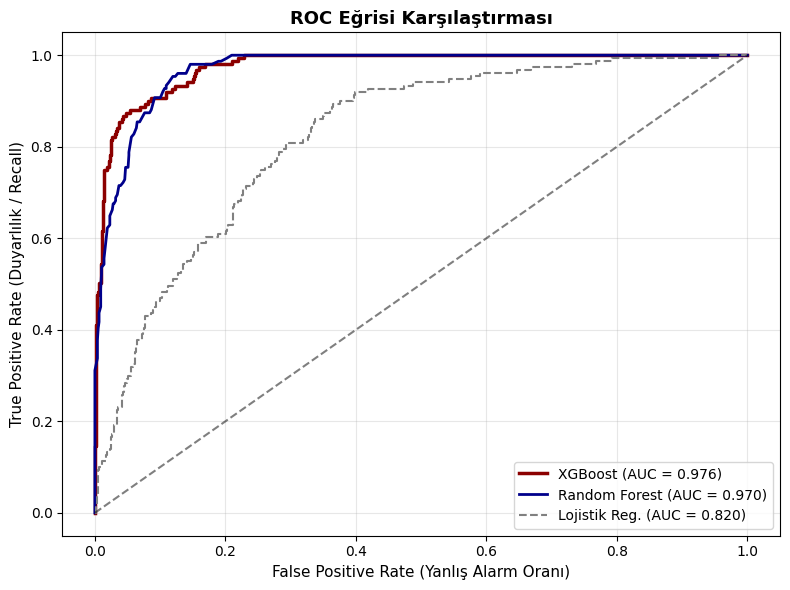

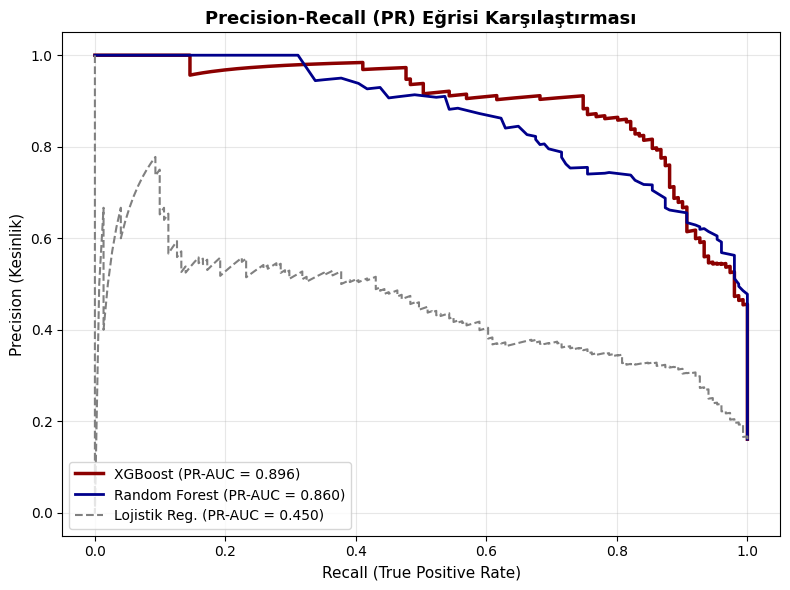

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# Modellerin tahmin olasılıklarını çekiyoruz (Sınıf 1 için)
y_prob_xgb = xgb_model.predict_proba(X_test_clean_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_clean_scaled)[:, 1]
y_prob_log = log_reg.predict_proba(X_test_clean_scaled)[:, 1]

# --- 1. GRAFİK: ROC EĞRİSİ ---
plt.figure(figsize=(8, 6))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = 0.976)', color='darkred', linewidth=2.5)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = 0.970)', color='darkblue', linewidth=2)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label='Lojistik Reg. (AUC = 0.820)', color='gray', linestyle='--', linewidth=1.5)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=11)
plt.ylabel('True Positive Rate (Duyarlılık / Recall)', fontsize=11)
plt.title('ROC Eğrisi Karşılaştırması', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_egrisi.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 2. GRAFİK: PR (PRECISION-RECALL) EĞRİSİ ---
plt.figure(figsize=(8, 6))
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(rec_xgb, prec_xgb, label='XGBoost (PR-AUC = 0.896)', color='darkred', linewidth=2.5)

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(rec_rf, prec_rf, label='Random Forest (PR-AUC = 0.860)', color='darkblue', linewidth=2)

prec_log, rec_log, _ = precision_recall_curve(y_test, y_prob_log)
plt.plot(rec_log, prec_log, label='Lojistik Reg. (PR-AUC = 0.450)', color='gray', linestyle='--', linewidth=1.5)

plt.xlabel('Recall (True Positive Rate)', fontsize=11)
plt.ylabel('Precision (Kesinlik)', fontsize=11)
plt.title('Precision-Recall (PR) Eğrisi Karşılaştırması', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_egrisi.png', dpi=300, bbox_inches='tight')
plt.show()